# 04 - Modelo: XGBoost con TF-IDF Bigrama

Entrena y evalúa un clasificador **XGBoost** sobre la codificación TF-IDF (uni+bigramas)
generada en `02_encoding-2.ipynb`.

## Flujo
1. Cargar artefactos TF-IDF desde `02_encoding-2.ipynb`.
2. Ajustar hiperparámetros clave de XGBoost con `X_val`.
3. Re-entrenar modelo final con `X_train_tfidf` completo.
4. Evaluar **una sola vez** sobre `X_test_tfidf`.
5. Registrar en MLflow.

## Política de evaluación
| Conjunto | Uso |
|---|---|
| `X_tr` | Entrenar durante ajuste de hiperparámetros |
| `X_val` | Validar para elegir mejor configuración |
| `X_train_tfidf` | Entrenamiento final |
| `X_test_tfidf` | Evaluación final única |

> ⚠️ XGBoost con matrices sparse de 100k features es costoso computacionalmente.
> Se recomienda ejecutar en GPU (`tree_method='hist', device='cuda'`) o reducir `max_features`
> en el vectorizador si el tiempo es limitado.


## 1. Instalación e imports

In [ ]:
!pip install -q scikit-learn scipy joblib matplotlib seaborn xgboost

In [ ]:
!pip install -q mlflow
import mlflow, mlflow.sklearn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.1/197.1 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 822.0/822.0 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 6.9 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

from scipy.sparse import load_npz
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)

sns.set_theme(style='whitegrid', palette='muted')
SEED = 42
print('OK - Imports listos. SEED:', SEED)


OK - Imports listos. SEED: 42


## 2. Carga de artefactos TF-IDF

In [ ]:
X_tr          = load_npz('X_tr.npz')
X_val         = load_npz('X_val.npz')
X_train_tfidf = load_npz('X_train_tfidf.npz')
X_test_tfidf  = load_npz('X_test_tfidf.npz')

y_tr    = joblib.load('y_tr.pkl')
y_val   = joblib.load('y_val.pkl')
y_train = joblib.load('y_train.pkl')
y_test  = joblib.load('y_test.pkl')

print('X_tr:          ', X_tr.shape)
print('X_val:         ', X_val.shape)
print('X_train_tfidf: ', X_train_tfidf.shape)
print('X_test_tfidf:  ', X_test_tfidf.shape)


X_tr:           (1088000, 100000)
X_val:          (272000, 100000)
X_train_tfidf:  (1360000, 100000)
X_test_tfidf:   (240000, 100000)


## 3. XGBoost para clasificación de texto

**XGBoost** (Extreme Gradient Boosting) es un modelo basado en ensamble de árboles de decisión
entrenados secuencialmente, donde cada árbol corrige los errores del anterior.

### Ventajas sobre Naive Bayes
- Captura relaciones no lineales entre features.
- No asume independencia entre palabras.
- Maneja matrices sparse nativamente con `tree_method='hist'`.

### Hiperparámetros clave a ajustar
| Parámetro | Descripción |
|---|---|
| `n_estimators` | Número de árboles |
| `max_depth` | Profundidad máxima de cada árbol |
| `learning_rate` | Tasa de aprendizaje (shrinkage) |
| `subsample` | Fracción de muestras por árbol |
| `colsample_bytree` | Fracción de features por árbol |


## 4. Ajuste de hiperparámetros

In [ ]:
# Grid reducido para tiempo razonable — ajusta según recursos disponibles
configs = [
    {'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.1},
    {'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.1},
    {'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.1},
    {'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.05},
]

results_hp = []
for cfg in configs:
    xgb = XGBClassifier(
        **cfg,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method='hist',     # eficiente con matrices sparse
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=SEED,
        n_jobs=-1
    )
    xgb.fit(X_tr, y_tr)
    y_pred_val = xgb.predict(X_val)
    f1  = f1_score(y_val, y_pred_val, average='macro')
    acc = accuracy_score(y_val, y_pred_val)
    results_hp.append({**cfg, 'f1_macro': round(f1, 4), 'accuracy': round(acc, 4)})
    print(f"n_est={cfg['n_estimators']:>3} | depth={cfg['max_depth']} "
          f"| lr={cfg['learning_rate']} | F1: {f1:.4f} | Acc: {acc:.4f}")

df_hp      = pd.DataFrame(results_hp)
best_idx   = df_hp['f1_macro'].idxmax()
best_cfg   = configs[best_idx]
print(f'\nMejor configuración: {best_cfg}')
print(df_hp.to_string(index=False))


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:52:33] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


n_est=100 | depth=4 | lr=0.1 | F1: 0.7080 | Acc: 0.7098


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:57:16] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


n_est=200 | depth=4 | lr=0.1 | F1: 0.7337 | Acc: 0.7346


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:06:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


n_est=100 | depth=6 | lr=0.1 | F1: 0.7262 | Acc: 0.7273


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:16:19] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


n_est=200 | depth=6 | lr=0.05 | F1: 0.7266 | Acc: 0.7277

Mejor configuración: {'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.1}
 n_estimators  max_depth  learning_rate  f1_macro  accuracy
          100          4           0.10    0.7080    0.7098
          200          4           0.10    0.7337    0.7346
          100          6           0.10    0.7262    0.7273
          200          6           0.05    0.7266    0.7277


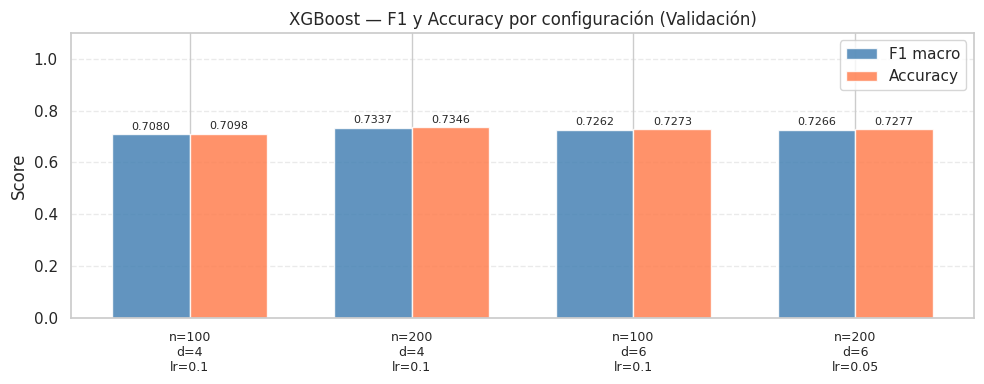

In [ ]:
labels = [f"n={c['n_estimators']}\nd={c['max_depth']}\nlr={c['learning_rate']}"
          for c in configs]
x = np.arange(len(labels))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 4))
b1 = ax.bar(x - w/2, df_hp['f1_macro'],  w, label='F1 macro',  color='steelblue', alpha=0.85)
b2 = ax.bar(x + w/2, df_hp['accuracy'],  w, label='Accuracy',  color='coral',     alpha=0.85)
ax.bar_label(b1, fmt='%.4f', fontsize=8, padding=2)
ax.bar_label(b2, fmt='%.4f', fontsize=8, padding=2)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('XGBoost — F1 y Accuracy por configuración (Validación)')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


## 5. Entrenamiento Final

Con la mejor configuración, re-entrenamos con **todo** `X_train_tfidf` (1,360,000 filas).


In [ ]:
model_final = XGBClassifier(
    **best_cfg,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=SEED,
    n_jobs=-1
)
model_final.fit(X_train_tfidf, y_train)
print(f'Modelo final entrenado: {best_cfg}')
print(f'Docs de entrenamiento:  {X_train_tfidf.shape[0]:,}')
print(f'Features (n-gramas):    {X_train_tfidf.shape[1]:,}')


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:35:02] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Modelo final entrenado: {'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.1}
Docs de entrenamiento:  1,360,000
Features (n-gramas):    100,000


In [ ]:
def get_metrics(y_true, y_pred, y_proba):
    return {
        'accuracy':  accuracy_score(y_true, y_pred),
        'f1_macro':  f1_score(y_true, y_pred, average='macro'),
        'precision': precision_score(y_true, y_pred, average='macro'),
        'recall':    recall_score(y_true, y_pred, average='macro'),
        'roc_auc':   roc_auc_score(y_true, y_proba),
    }


## 6. Evaluación Final en Test

Este es el **único momento** en que usamos `X_test_tfidf`.


In [ ]:
y_pred_test  = model_final.predict(X_test_tfidf)
y_proba_test = model_final.predict_proba(X_test_tfidf)[:, 1]
metrics_test = get_metrics(y_test, y_pred_test, y_proba_test)

# Métricas train para comparativa
y_pred_train  = model_final.predict(X_train_tfidf)
y_proba_train = model_final.predict_proba(X_train_tfidf)[:, 1]
metrics_train = get_metrics(y_train, y_pred_train, y_proba_train)

# Métricas val
y_pred_val_f  = model_final.predict(X_val)
y_proba_val_f = model_final.predict_proba(X_val)[:, 1]
metrics_val   = get_metrics(y_val, y_pred_val_f, y_proba_val_f)

print('=== EVALUACIÓN FINAL — XGBoost + TF-IDF Bigrama ===')
print(f'  Accuracy:  {metrics_test["accuracy"]:.4f}')
print(f'  F1 macro:  {metrics_test["f1_macro"]:.4f}')
print(f'  Precision: {metrics_test["precision"]:.4f}')
print(f'  Recall:    {metrics_test["recall"]:.4f}')
print(f'  ROC-AUC:   {metrics_test["roc_auc"]:.4f}')
print()
print(classification_report(y_test, y_pred_test, target_names=['Negativo (0)', 'Positivo (1)']))


=== EVALUACIÓN FINAL — XGBoost + TF-IDF Bigrama ===
  Accuracy:  0.7393
  F1 macro:  0.7385
  Precision: 0.7425
  Recall:    0.7394
  ROC-AUC:   0.8188

              precision    recall  f1-score   support

Negativo (0)       0.77      0.68      0.72    120129
Positivo (1)       0.71      0.80      0.75    119871

    accuracy                           0.74    240000
   macro avg       0.74      0.74      0.74    240000
weighted avg       0.74      0.74      0.74    240000



### 6.1 Gráfica: Métricas Train / Val / Test

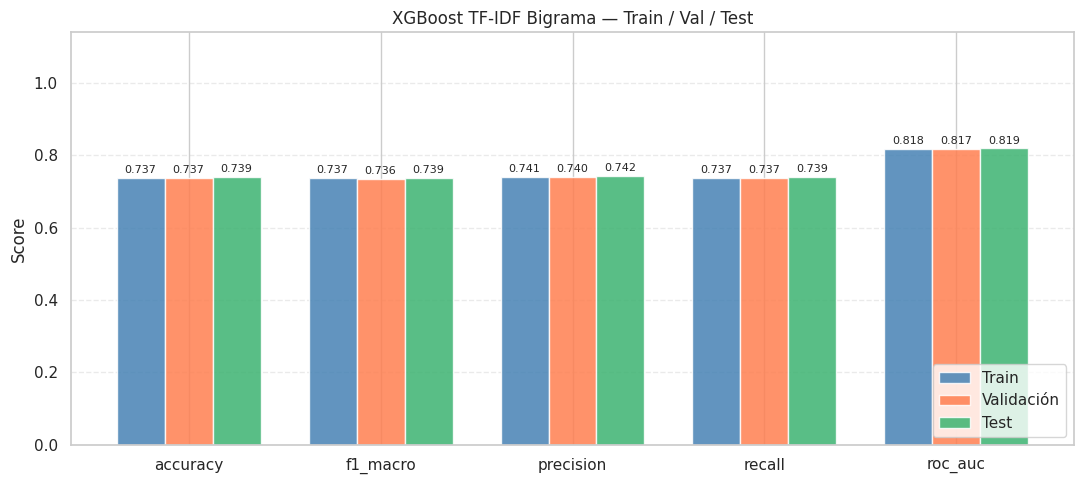

In [ ]:
metric_names = ['accuracy', 'f1_macro', 'precision', 'recall', 'roc_auc']
x = np.arange(len(metric_names))
w = 0.25

vals_tr   = [metrics_train[m] for m in metric_names]
vals_val  = [metrics_val[m]   for m in metric_names]
vals_test = [metrics_test[m]  for m in metric_names]

fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x - w, vals_tr,   w, label='Train',      color='steelblue',      alpha=0.85)
b2 = ax.bar(x,     vals_val,  w, label='Validación', color='coral',          alpha=0.85)
b3 = ax.bar(x + w, vals_test, w, label='Test',       color='mediumseagreen', alpha=0.85)

for bars in (b1, b2, b3):
    ax.bar_label(bars, fmt='%.3f', fontsize=8, padding=2)

ax.set_xticks(x)
ax.set_xticklabels(metric_names, fontsize=11)
ax.set_ylim(0, 1.14)
ax.set_ylabel('Score')
ax.set_title(f'XGBoost TF-IDF Bigrama — Train / Val / Test')
ax.legend(fontsize=11, loc='lower right')
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


### 6.2 Matriz de Confusión — Test Final

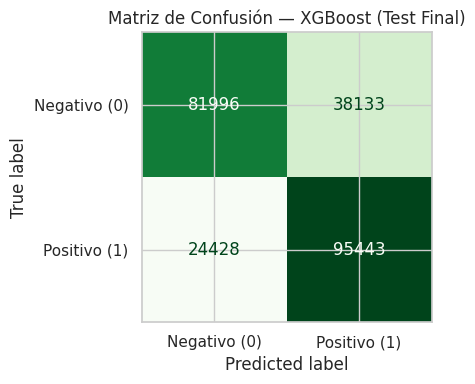

In [ ]:
cm   = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(cm, display_labels=['Negativo (0)', 'Positivo (1)'])

fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False, cmap='Greens')
ax.set_title('Matriz de Confusión — XGBoost (Test Final)')
plt.tight_layout()
plt.show()


### 6.3 Top 20 features más importantes

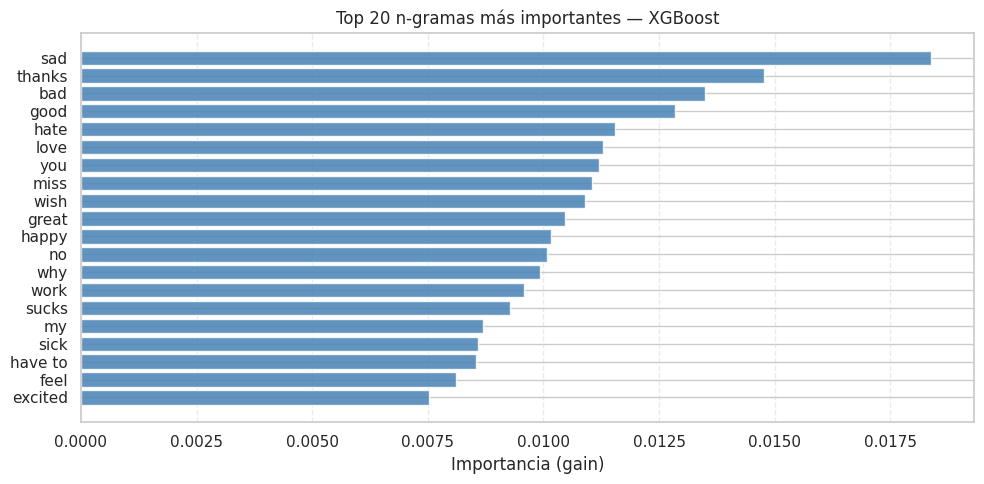

In [ ]:
vectorizer    = joblib.load('tfidf_vectorizer.pkl')
feature_names = vectorizer.get_feature_names_out()
importances   = model_final.feature_importances_
top20_idx     = np.argsort(importances)[::-1][:20]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(feature_names[top20_idx][::-1], importances[top20_idx][::-1],
        color='steelblue', alpha=0.85)
ax.set_xlabel('Importancia (gain)')
ax.set_title('Top 20 n-gramas más importantes — XGBoost')
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


## 7. Guardar modelo y resultados

In [ ]:
joblib.dump(model_final, 'xgb_tfidf_model.pkl')

results_final = pd.DataFrame([{
    'modelo':      'XGBoost',
    'encoding':    'TF-IDF Bigrama',
    **{f'best_{k}': v for k, v in best_cfg.items()},
    'train_acc':   round(metrics_train['accuracy'],  4),
    'train_f1':    round(metrics_train['f1_macro'],  4),
    'train_auc':   round(metrics_train['roc_auc'],   4),
    'val_acc':     round(metrics_val['accuracy'],    4),
    'val_f1':      round(metrics_val['f1_macro'],    4),
    'val_auc':     round(metrics_val['roc_auc'],     4),
    'test_acc':    round(metrics_test['accuracy'],   4),
    'test_f1':     round(metrics_test['f1_macro'],   4),
    'test_auc':    round(metrics_test['roc_auc'],    4),
}])

results_final.to_csv('results_xgb.csv', index=False)
print('Guardados: xgb_tfidf_model.pkl | results_xgb.csv')
print()
print(results_final.T.to_string(header=False))


Guardados: xgb_tfidf_model.pkl | results_xgb.csv

modelo                     XGBoost
encoding            TF-IDF Bigrama
best_n_estimators              200
best_max_depth                   4
best_learning_rate             0.1
train_acc                   0.7375
train_f1                    0.7366
train_auc                    0.818
val_acc                     0.7365
val_f1                      0.7357
val_auc                     0.8175
test_acc                    0.7393
test_f1                     0.7385
test_auc                    0.8188


## 8. Predicción en Vivo

In [ ]:
import re

try: vectorizer
except NameError: vectorizer = joblib.load('tfidf_vectorizer.pkl')
try: model_final
except NameError: model_final = joblib.load('xgb_tfidf_model.pkl')

def clean_raw_text(text):
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'[^\x00-\x7F]+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# ════════════════════════════════════════════════════
# ↓↓↓  CAMBIA ESTE TEXTO  ↓↓↓
texto = "I absolutely love this product, it made my day so much better!"
# ════════════════════════════════════════════════════

texto_limpio = clean_raw_text(texto)
X_input      = vectorizer.transform([texto_limpio])
pred         = model_final.predict(X_input)[0]
proba        = model_final.predict_proba(X_input)[0]

label     = '😊 Positivo' if pred == 1 else '😞 Negativo'
confianza = proba[pred]
barra     = '█' * int(confianza * 30) + '░' * (30 - int(confianza * 30))

print('─' * 50)
print(f'  Texto original : {texto}')
print(f'  Texto limpio   : {texto_limpio}')
print('─' * 50)
print(f'  Predicción     : {label}')
print(f'  Confianza      : {confianza:.1%}  {barra}')
print(f'  P(Negativo)    : {proba[0]:.4f}')
print(f'  P(Positivo)    : {proba[1]:.4f}')
print('─' * 50)


──────────────────────────────────────────────────
  Texto original : I absolutely love this product, it made my day so much better!
  Texto limpio   : I absolutely love this product, it made my day so much better!
──────────────────────────────────────────────────
  Predicción     : 😊 Positivo
  Confianza      : 73.3%  █████████████████████░░░░░░░░░
  P(Negativo)    : 0.2671
  P(Positivo)    : 0.7329
──────────────────────────────────────────────────


## 9. Registro en MLflow

In [ ]:
mlflow.set_tracking_uri("http://ec2-52-5-36-177.compute-1.amazonaws.com:5000")
mlflow.set_experiment("Parcial_1_NLP")

with mlflow.start_run(run_name="XGBoost_TFIDFBigrama") as run:

    # ── Tags ──────────────────────────────────────────────────────────────────
    mlflow.set_tags({
        "user":       "Juan Camilo Gallardo",
        "model_type": "XGBoost",
        "encoding":   "TF-IDF Bigrama",
        "dataset":    "Sentiment140Twitter",
    })

    # ── Parámetros de preprocesamiento ────────────────────────────────────────
    mlflow.log_params({
        "prep_remove_urls":      True,
        "prep_remove_mentions":  True,
        "prep_remove_hashtags":  True,
        "prep_remove_emojis":    True,
        "prep_remove_stopwords": False,
        "prep_lemmatization":    False,
    })

    # ── Parámetros de codificación ────────────────────────────────────────────
    mlflow.log_params({
        "vec_type":         "TfidfVectorizer",
        "vec_max_features": 100000,
        "vec_min_df":       5,
        "vec_max_df":       0.95,
        "vec_ngram_range":  "(1,2)",
        "vec_sublinear_tf": True,
    })

    # ── Parámetros del modelo ─────────────────────────────────────────────────
    mlflow.log_params({
        "model":            "XGBoost",
        "n_estimators":     best_cfg['n_estimators'],
        "max_depth":        best_cfg['max_depth'],
        "learning_rate":    best_cfg['learning_rate'],
        "subsample":        0.8,
        "colsample_bytree": 0.8,
        "tree_method":      "hist",
        "seed":             SEED,
        "train_size":       X_train_tfidf.shape[0],
        "val_size":         X_val.shape[0],
        "test_size":        X_test_tfidf.shape[0],
        "vocab_size":       X_train_tfidf.shape[1],
    })

    # ── Métricas Train ────────────────────────────────────────────────────────
    mlflow.log_metrics({
        "train_accuracy":  round(metrics_train['accuracy'],  4),
        "train_f1_macro":  round(metrics_train['f1_macro'],  4),
        "train_precision": round(metrics_train['precision'], 4),
        "train_recall":    round(metrics_train['recall'],    4),
        "train_roc_auc":   round(metrics_train['roc_auc'],   4),
    })

    # ── Métricas Validación ───────────────────────────────────────────────────
    mlflow.log_metrics({
        "val_accuracy":    round(metrics_val['accuracy'],  4),
        "val_f1_macro":    round(metrics_val['f1_macro'],  4),
        "val_precision":   round(metrics_val['precision'], 4),
        "val_recall":      round(metrics_val['recall'],    4),
        "val_roc_auc":     round(metrics_val['roc_auc'],   4),
    })

    # ── Métricas Test ─────────────────────────────────────────────────────────
    mlflow.log_metrics({
        "test_accuracy":   round(metrics_test['accuracy'],  4),
        "test_f1_macro":   round(metrics_test['f1_macro'],  4),
        "test_precision":  round(metrics_test['precision'], 4),
        "test_recall":     round(metrics_test['recall'],    4),
        "test_roc_auc":    round(metrics_test['roc_auc'],   4),
    })

    # ── Artefactos ────────────────────────────────────────────────────────────
    mlflow.log_artifact("results_xgb.csv")
    mlflow.sklearn.log_model(model_final, artifact_path="model",
                             registered_model_name="XGBoost_TFIDFBigrama")

    print("=" * 55)
    print("  ✅ Run registrado en MLflow")
    print(f"  Servidor    : http://ec2-52-5-36-177.compute-1.amazonaws.com:5000")
    print(f"  Experimento : Parcial_1_NLP")
    print(f"  Corrida     : XGBoost_TFIDFBigrama")
    print(f"  Run ID      : {run.info.run_id}")
    print(f"  Test F1     : {metrics_test['f1_macro']:.4f}")
    print(f"  Test AUC    : {metrics_test['roc_auc']:.4f}")
    print("=" * 55)


2026/03/09 18:48:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/09 18:48:09 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'XGBoost_TFIDFBigrama'.
2026/03/09 18:48:18 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: XGBoost_TFIDFBigrama, version 1
Created version '1' of model 'XGBoost_TFIDFBigrama'.


  ✅ Run registrado en MLflow
  Servidor    : http://ec2-52-5-36-177.compute-1.amazonaws.com:5000
  Experimento : Parcial_1_NLP
  Corrida     : XGBoost_TFIDFBigrama
  Run ID      : e2e61e8e51314b6cbcdf4756b6cc3d9f
  Test F1     : 0.7385
  Test AUC    : 0.8188
🏃 View run XGBoost_TFIDFBigrama at: http://ec2-52-5-36-177.compute-1.amazonaws.com:5000/#/experiments/1/runs/e2e61e8e51314b6cbcdf4756b6cc3d9f
🧪 View experiment at: http://ec2-52-5-36-177.compute-1.amazonaws.com:5000/#/experiments/1
